[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FranQuant/llm-regime-allocator/blob/main/notebooks/nb05_counterfactual.ipynb)

In [1]:
# Setup. On Colab this fetches the repo (data, results, replayable LLM cache); locally it does nothing.
# No API keys or paid calls are needed anywhere in this notebook.
import os, subprocess, sys
if 'google.colab' in sys.modules:
    REPO = '/content/llm-regime-allocator'
    if not os.path.exists(REPO):
        subprocess.run(['git', 'clone', '-q', '--depth', '1', 'https://github.com/FranQuant/llm-regime-allocator.git', REPO], check=True)
    sys.path.insert(0, f'{REPO}/src')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from lra import viz
viz.apply_style()

# nb05 — Reading or remembering? Edit the data and re-ask

**Question.** GPT names the month of almost any blinded snapshot. When it calls a regime, does it read the figures or recall what happened? Change the figures: a model that reads should change its answer, one that remembers has no reason to. Read from `scripts/score_phase9.py` output; no API calls.

## Setup

**Edits.** On the blinded snapshot, flip the sign of every inflation z-score (headline and core CPI; 6 numbers) or of every growth z-score (industrial production, activity, payrolls, unemployment; 12 numbers). Everything else stays.

**Months.** 30 per edit, half with the block clearly up and half clearly down, spread over 2007–2026 by a fixed rule (`configs/phase9.toml`, committed before any paid call).

**Test.** How far the answer moves under the edit, against how far it moves when the *unedited* snapshot is simply asked again:
$$\mathrm{moved}_t=\mathrm{TV}(p^{\text{edit}}_t,p_t),\qquad \mathrm{noise}_t=\mathrm{TV}(p^{\text{re-ask}}_t,p_t).$$
A model *reads the data* if the mean of $\mathrm{moved}_t-\mathrm{noise}_t$ has a 95% interval above zero for both edits. Walk-forward ML on the same inputs is a yardstick that cannot remember anything (noise = 0).

In [2]:
P9 = viz.RESULTS / 'phase9'
NAME = {**viz.MODEL_NAMES, 'ml_logit_blinded': 'ML logit', 'ml_gbt_blinded': 'ML GBT'}
COL = {**viz.MODEL_COLORS, 'ml_logit_blinded': viz.GREYS['ml'], 'ml_gbt_blinded': viz.GREYS['uniform']}
sh = pd.read_csv(P9 / 'shifts.csv')

## 1. One month: December 2021

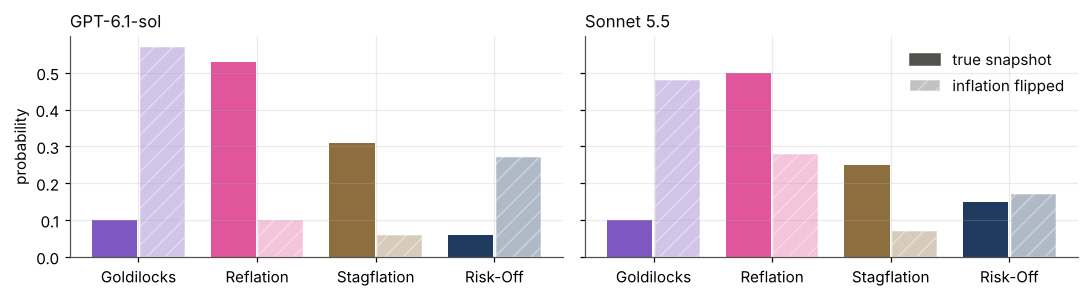

In [3]:
d = '2021-12-31'
fig, axes = plt.subplots(1, 2, figsize=(10, 2.8), sharey=True)
for ax, m in zip(axes, ['gpt_sol', 'claude_sonnet']):
    before = viz.read(f'results/llm/{m}/blinded_run0.csv').loc[d, viz.REGIMES].astype(float)
    after = viz.read(f'results/llm/{m}/blinded_cf_infl_run0.csv').loc[d, viz.REGIMES].astype(float)
    x = np.arange(4)
    ax.bar(x - 0.2, before, 0.38, color=[viz.REGIME_COLORS[k] for k in viz.REGIMES], label='true snapshot')
    ax.bar(x + 0.2, after, 0.38, color=[viz.REGIME_COLORS[k] for k in viz.REGIMES], alpha=0.35,
           hatch='//', edgecolor='white', label='inflation flipped')
    ax.set_xticks(x, [k.replace('_', '-') for k in viz.REGIMES]); ax.set_title(viz.MODEL_NAMES[m])
from matplotlib.patches import Patch
axes[0].set_ylabel('probability')
axes[1].legend(handles=[Patch(color=viz.MUTED, label='true snapshot'), Patch(facecolor=viz.MUTED, alpha=0.35, hatch='//', edgecolor='white', label='inflation flipped')], loc='upper right'); plt.tight_layout(); plt.show()

**Reading.** Late 2021, inflation surging; GPT can name this month from the blinded snapshot. Told instead that inflation is cooling, with everything else unchanged, GPT moves from 84% to 16% on the inflation-up regimes (Reflation + Stagflation), Sonnet from 75% to 35%.

## 2. Every model follows the edit, far beyond its noise

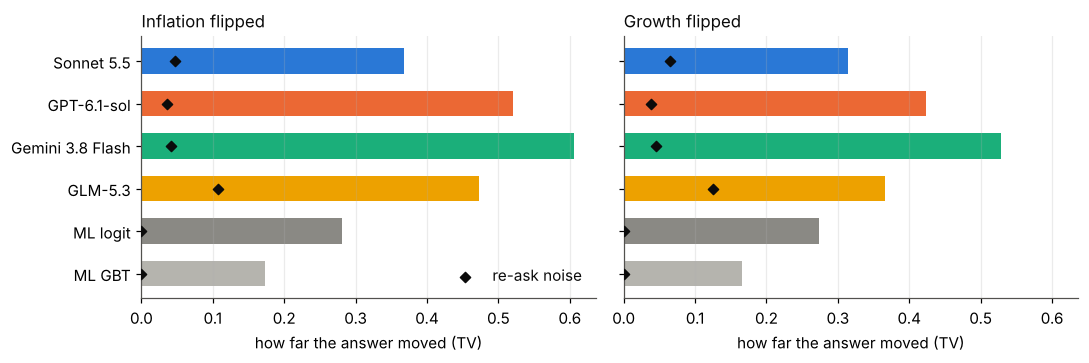

In [4]:
order = list(NAME)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), sharex=True, sharey=True)
for ax, e, title in zip(axes, ('infl', 'growth'), ('Inflation flipped', 'Growth flipped')):
    s = sh[sh.edit == e].set_index('forecaster').loc[order]
    y = np.arange(len(s))[::-1]
    ax.barh(y, s.moved_tv, color=[COL[k] for k in s.index], height=0.6)
    ax.scatter(s.noise_tv, y, color=viz.INK, zorder=3, s=22, marker='D', label='re-ask noise')
    ax.set_yticks(y, [NAME[k] for k in s.index]); ax.set_title(title); ax.grid(axis='y', visible=False)
    ax.set_xlabel('how far the answer moved (TV)')
axes[0].legend(loc='lower right'); plt.tight_layout(); plt.show()
t = sh.assign(forecaster=sh.forecaster.map(NAME)).set_index(['forecaster', 'edit'])
viz.fmt(t[['moved_tv', 'noise_tv', 'moved_minus_noise', 'ci_lo', 'ci_hi', 'follow_rate']], pct=['follow_rate'])

**Reading.** **Key finding:** all four LLMs pass the pre-registered test. Under either edit their answer moves 0.31–0.61, against 0.04–0.13 when merely re-asked, and in the direction the edited figures imply in 87–100% of months. **Control:** the ML models, which cannot remember, move less (0.17–0.28) and follow the growth edit in under a third of months; over three months a strong growth reading can legitimately precede a slowdown, so the LLMs' answers track the textbook reading of the regimes more than the historical one.

## 3. Does knowing the month make a model ignore the data?

In [5]:
s2 = pd.read_csv(P9 / 'secondary.csv')
viz.fmt(s2[s2.comparison.str.startswith('gpt_sol minus')].set_index(['comparison', 'edit']).drop(columns='n'))

**Reading.** No. GPT, which dates almost every one of these snapshots, follows the edits *more* than Sonnet (+0.16 and +0.14 in moved minus noise, intervals above zero).

## What we can and cannot claim

- **The answers are not a lookup of the month.** Change the figures and every model changes its call, the way the figures imply and far beyond its run-to-run noise, GPT included.
- **This is sensitivity, not skill.** A model can read the figures *and* lean on what it remembers; an edited snapshot may simply look like a different episode. Following the figures is not the same as being right.
- **Limits.** 30 months per edit, one edit size (a full sign flip), one run per edited snapshot; edited snapshots are internally inconsistent by design.

## Next

The one test memory cannot touch is prospective. nb06 is the live log.